# Predicción de mora temprana en microcréditos MYPE
**Notebook 03 · Separación, pipeline, modelos preliminares y evaluación**

Requiere haber ejecutado el notebook 02.

In [7]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sys.path.append("..")

df = pd.read_csv(
    "../data/processed/creditos_limpio.csv",
    parse_dates=["fecha_solicitud", "fecha_desembolso"],
)

## 5. Separación de los datos

### 5.1 Variables del modelo

In [8]:
# Excluir de X: identificadores, variables con fuga y la propia variable objetivo.

TARGET = "mora_30d_6m"
COLS_ID = ["id_credito", "id_cliente"]
COLS_FECHA = ["fecha_solicitud", "fecha_desembolso"]
COLS_EXCLUIR = COLS_ID + COLS_FECHA + [TARGET]

y = df["mora_30d_6m"]
X = df.drop(columns=COLS_EXCLUIR)


**Variables excluidas y motivo:**

- Se excluyeron las variables fechas, pues se aporte sirve mas para otros modelos que dependen de la estacionalidad, en el caso del modelo clasificador usado, dependera de la  variable mora_30d_6m, como aprendizaje supervisado.
- Se excluyo mora_30d_6m de X pues es la variable objetivo
- Se excluyeron los ID, pues no aportan informacion importante para el modelo. Su importancia puede ir mas por el analisis EDA, pero no para el entrenamiento, ya que no poseen algun comportamiento importante.

### 5.2 Estrategia de separación


In [11]:
conteo = df.groupby(df["fecha_desembolso"].dt.to_period("Q")).size()
resumen = pd.DataFrame({
    "creditos": conteo,
    "proporcion_acumulada": conteo.cumsum() / conteo.sum(),
    "tasa_mora": df.groupby(df["fecha_desembolso"].dt.to_period("Q"))["mora_30d_6m"].mean(),
})
resumen

,creditos,proporcion_acumulada,tasa_mora
fecha_desembolso,,,
2022Q1,752,0.048847,0.117021
2022Q2,1000,0.113803,0.099000
2022Q3,1126,0.186944,0.099467
2022Q4,1210,0.265541,0.116529
2023Q1,1235,0.345762,0.124696
2023Q2,1306,0.430594,0.138591
2023Q3,1367,0.519389,0.145574
2023Q4,1405,0.610653,0.106762
2024Q1,1435,0.703865,0.101742


La mora sube en 2023, pues llega a 14% en 2023Q3 y baja en 2024. Por eso se separo respetando el orden del tiempo: asi se imita el uso real del modelo, que siempre evaluara creditos posteriores a los que conoce.

In [12]:
CORTE_VAL = "2024-04-01"    # validación: 2024Q2 – 2024Q3
CORTE_TEST = "2024-10-01"   # test: 2024Q4

fechas = df["fecha_desembolso"] # Fechas para realizar corte

masc_train = fechas < CORTE_VAL
masc_val = (fechas >= CORTE_VAL) & (fechas < CORTE_TEST)
masc_test = fechas >= CORTE_TEST

X_train, y_train = X[masc_train], y[masc_train]
X_val, y_val = X[masc_val], y[masc_val]
X_test, y_test = X[masc_test], y[masc_test]

In [13]:
verificacion = pd.DataFrame({
    "conjunto": ["train", "validation", "test"],
    "creditos": [len(y_train), len(y_val), len(y_test)],
    "moras": [y_train.sum(), y_val.sum(), y_test.sum()],
    "tasa_mora": [y_train.mean(), y_val.mean(), y_test.mean()],
    "fecha_min": [fechas[masc_train].min(), fechas[masc_val].min(), fechas[masc_test].min()],
    "fecha_max": [fechas[masc_train].max(), fechas[masc_val].max(), fechas[masc_test].max()],
})
verificacion["porcentaje"] = verificacion["creditos"] / verificacion["creditos"].sum()
verificacion

,conjunto,creditos,moras,tasa_mora,fecha_min,fecha_max,porcentaje
0,train,10836,1270,0.117202,2022-01-01,2024-03-31,0.703865
1,validation,3031,267,0.088090,2024-04-01,2024-09-30,0.196882
2,test,1528,142,0.092932,2024-10-01,2024-12-30,0.099253


In [14]:
clientes = df["id_cliente"]
clientes_train = set(clientes[masc_train])
print("Clientes de validation que ya estaban en train:", len(set(clientes[masc_val]) & clientes_train))
print("Clientes de test que ya estaban en train:", len(set(clientes[masc_test]) & clientes_train))

Clientes de validation que ya estaban en train: 983
Clientes de test que ya estaban en train: 516


**Estrategia y proporciones:**

Se uso una separacion temporal: train hasta 2024Q1 (70%), validation 2024Q2 y 2024Q3 (20%) y test 2024Q4 (10%).

**Justificacion:**

Se evito usar aleatorizacion estratificada, pues se mezclarian creditos de distintos periodos en el train y test. Si esto sucede, el modelo podria entrenarse con creditos posteriores y evaluarse con creditos anteriores, lo cual en la practica es imposible, pues al momento de evaluar una solicitud solo se conoce informacion del pasado. Por ello, las metricas saldrian mas optimistas de lo que el modelo rendiria en realidad.

Ademas, la tasa de mora cambia en el tiempo, como se ve en la siguiente tabla por trimestre:

**Medidas contra el data leakage:**



## 6. Flujo reproducible de preprocesamiento

In [15]:
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

print(f"Numericas ({len(num_cols)}) :", num_cols)
print(f"Categoricas ({len(cat_cols)}) :", cat_cols)

Numericas (18) : ['edad', 'num_dependientes', 'antiguedad_negocio_meses', 'ingreso_mensual_declarado', 'gasto_mensual_declarado', 'num_creditos_previos_entidad', 'score_buro', 'max_dias_atraso_12m', 'num_entidades_sistema', 'deuda_total_sistema', 'num_consultas_buro_6m', 'monto_solicitado', 'score_buro_faltante', 'antiguedad_negocio_meses_faltante', 'ingreso_mensual_declarado_faltante', 'gasto_mensual_declarado_faltante', 'nivel_educativo_faltante', 'telefono_verificado_faltante']
Categoricas (12) : ['region', 'codigo_asesor', 'canal_captacion', 'sexo', 'estado_civil', 'nivel_educativo', 'tipo_vivienda', 'rubro', 'cliente_recurrente', 'calificacion_sbs', 'tiene_garantia', 'telefono_verificado']


In [ ]:

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols),
])

In [17]:
def evaluar(modelo, X, y, nombre):
    pred = modelo.predict(X)
    proba = modelo.predict_proba(X)[:, 1]
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "roc_auc": roc_auc_score(y, proba),
        "avg_precision": average_precision_score(y, proba)
    }

**Transformaciones por tipo de variable:**
- Numericas: Se realizo una imputacion con la mediana, porque varias variables como ingresos, montos y deuda son asimetricas y  tenias valores extremos. Luego se aplico un escalado, debido a que la regresion logistica es sensible a la escala. Si no se aplicara, una variable que va entre 500 a 6000 valdria mas frente a otro que va de 0 a 10, lo cual no es asi.
- Categoricas: Se realizo la imputacion con la moda y luego se aplico one hot encoding, pues los modelos necesitan numeros, no texto.

**Momento de ajuste y por qué evita la fuga de información:**

El pipeline solo aprende con train, al ejecutar `.fit(X_train, y_train)`. En ese momento calcula la mediana y la moda para imputar, la media y la desviacion para escalar y las categorias del one-hot. Luego aplica esos mismos valores a validation y test, sin recalcularlos.

Asi, ningun dato de validation o test influye en el aprendizaje del modelo. Si influyera, el modelo ya tendria nocion de los datos con los que se evalua, y las metricas saldrian optimistas, sin reflejar el desempeno real.

## 7. Baseline

In [26]:

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

resultados = [evaluar(baseline, X_val, y_val, "Baseline - Dummy")]
resultados

[{'modelo': 'Baseline - Dummy',
  'accuracy': 0.9119102606400528,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'roc_auc': 0.5,
  'avg_precision': 0.08808973935994721}]

**Interpretacion:**

El baseline DummyClassifier con most_frequent predice siempre la clase mas comun, "sin mora", para todos los creditos, sin mirar ninguna variable.

Su accuracy en validation es de 0.912, que parece alta, pero solo refleja que el 91.2% de los creditos de ese periodo no cayeron en mora. En cambio, su recall, precision y F1 son 0, es decir,  no detecta ningun credito que cae en mora. 

Este resultado muestra que la accuracy no sirve para comparar modelos en este problema, pues un modelo inutil ya obtiene 91%. Por eso la comparacion se hara con recall, precision, F1, ROC-AUC y average precision. Cualquier modelo propuesto debe superar claramente estos valores para considerarse util.

## 8. Modelos preliminares

### 8.1 Regresión logística

**Por qué este modelo:** La regresion logistica es el modelo estandar en scoring crediticio. Ademas es interpretable, ya que sus coeficientes indican cuanto aumenta o disminuye el riesgo de mora con cada variable, lo cual permite al comite justificar sus decisiones. Tambien, entrega una probabilidad de mora para cada credito, que es justamente lo que se necesita. 

In [ ]:
logistic = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

logistic.fit(X_train,y_train)

resultados.append(evaluar(logistic, X_val, y_val, "Regresion Logistica"))

### 8.2 Segundo modelo

**Por qué este modelo:** Random Forest combina muchos arboles de decision, lo que le permite captar relaciones no lineales e interacciones entre variables. Al combinar varios arboles, reduce el sobreajuste de un arbol individual. Su principal limitacion es que es menos interpretable que la regresion logistica.

In [ ]:
forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
])
forest.fit(X_train, y_train)

resultados.append(evaluar(forest, X_val, y_val, "Random Forest"))

## 9. Evaluación preliminar

### 9.1 Métricas elegidas

No se usa accuracy, debido a que un modelo que nunca predice mora ya obtiene 91%.

| Metrica | Que mide | Uso |
|---|---|---|
| Recall | Moras detectadas | Prioritaria: el falso negativo es el error mas costoso |
| Precision | Acierto al marcar riesgo | Evita marcar a buenos pagadores |
| F1 | Balance precision-recall | Comparar modelos con un mismo umbral |
| ROC-AUC | Capacidad de distinguir | Comparar modelos sin depender del umbral |
| Average precision | Area bajo la curva PR | Comparar modelos con clases desbalanceadas |

### 9.2 Comparación de modelos

In [ ]:
tabla = pd.DataFrame(resultados).set_index("modelo").round(3)
tabla

,accuracy,precision,recall,f1,roc_auc,avg_precision
modelo,,,,,,
Baseline - Dummy,0.912,0.000,0.000,0.000,0.500,0.088
Regresion Logistica,0.930,0.669,0.401,0.501,0.861,0.516
Random Forest,0.928,0.695,0.333,0.451,0.850,0.512


**Interpretacion:**

Ambos modelos superan claramente al baseline. Su ROC-AUC de 0.86 indica que distinguen bien entre buenos y malos pagadores, y su average precision de 0.51 es casi 6 veces la del baseline 0.088. La accuracy, en cambio, apenas sube de 0.912 a 0.930, lo que confirma que no sirve para comparar en este problema.

La regresion logistica obtiene resultados iguales o ligeramente mejores que Random Forest. Al ser ademas mas interpretable, resulta la opcion mas adecuada para el comite.

Sin embargo, con el umbral de 0.5 ambos modelos detectan menos del 40% de los creditos que caen en mora. Este recall bajo se analiza ajustando el umbral en la seccion 9.4.

### 9.3 Matriz de confusión

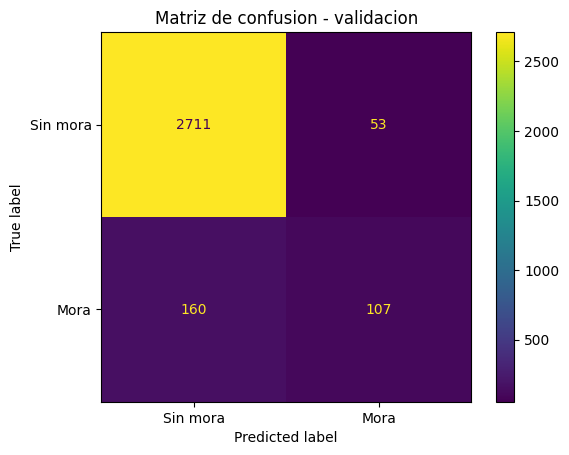

In [27]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    logistic.predict(X_val),
    display_labels=["Sin mora", "Mora"],
)

plt.title("Matriz de confusion - validacion")
plt.show()

**Interpretacion:**

- **Verdaderos positivos (107):** creditos que cayeron en mora y el modelo marco como riesgosos. 
- **Falsos negativos (160):** creditos que cayeron en mora y el modelo no alerto. Es el error mas costoso, porque implica perder dinero.
- **Falsos positivos (53):** buenos pagadores marcados como riesgosos. Su costo es menor. Es necesaria una revision adicional o condiciones mas estrictas para un buen cliente.
- **Verdaderos negativos (2711):** buenos pagadores identificados correctamente.

Con el umbral de 0.5, el modelo deja escapar 164 de las 267 moras (61%) y solo marca a 57 buenos pagadores. Es decir, comete mas el error caro que el barato, lo contrario a lo que conviene segun los criterios de utilidad. Por eso se evalua un umbral menor en la seccion 9.4.

### 9.4 Efecto del umbral de decisión

In [ ]:
proba_val = logistic.predict_proba(X_val)[:, 1]

filas = []

for umbral in [0.10, 0.20, 0.30, 0.50, 0.70]:
    pred = (proba_val >= umbral).astype(int)
    filas.append({
        "umbral": umbral,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred),
        "f1": f1_score(y_val, pred),
        "marcados_riesgosos": pred.sum(),
        "moras_detectadas": ((pred == 1) & (y_val == 1)).sum(),
        "buenos_marcados": ((pred == 1) & (y_val == 0)).sum(),
    })

pd.DataFrame(filas).round(3)

,umbral,precision,recall,f1,marcados_riesgosos,moras_detectadas,buenos_marcados
0,0.1,0.242,0.779,0.369,861,208,653
1,0.2,0.386,0.637,0.481,440,170,270
2,0.3,0.500,0.543,0.521,290,145,145
3,0.5,0.669,0.401,0.501,160,107,53
4,0.7,0.756,0.221,0.342,78,59,19


**Interpretacion:**
El umbral de 0.3 obtiene el mejor F1 (0.521) y equilibra ambos errores. Ademas, detecta 145 moras y marca 145 buenos pagadores.

Como el modelo se usa como apoyo y los creditos marcados pasan a revision del comite , marcar a un buen pagador tiene un costo bajo. Por eso, un umbral entre 0.2 y 0.3 resulta mas adecuado que 0.5. 

### 9.5 Curvas Precision–Recall y ROC

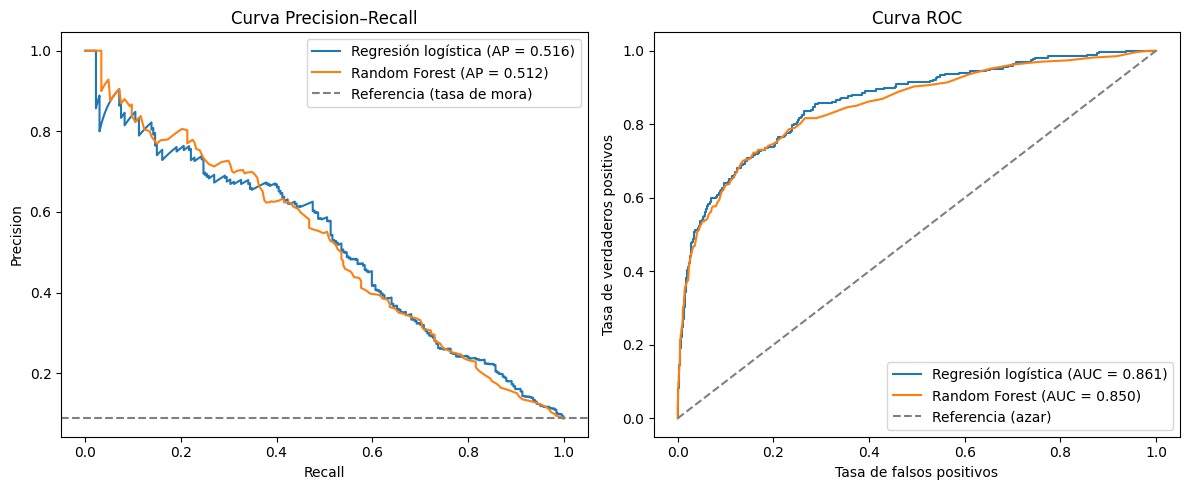

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for nombre, modelo in [("Regresión logística", logistic), ("Random Forest", forest)]:
    proba = modelo.predict_proba(X_val)[:, 1]

    precision, recall, _ = precision_recall_curve(y_val, proba)
    axes[0].plot(recall, precision, label=f"{nombre} (AP = {average_precision_score(y_val, proba):.3f})")

    fpr, tpr, _ = roc_curve(y_val, proba)
    axes[1].plot(fpr, tpr, label=f"{nombre} (AUC = {roc_auc_score(y_val, proba):.3f})")

axes[0].axhline(y_val.mean(), linestyle="--", color="gray", label="Referencia (tasa de mora)")
axes[0].set(title="Curva Precision–Recall", xlabel="Recall", ylabel="Precision")
axes[0].legend()

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Referencia (azar)")
axes[1].set(title="Curva ROC", xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos")
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretacion:**

En la curva ROC estan muy por encima de la diagonal del azar, y en la curva Precision-Recall muy por encima de la tasa de mora.

Las curvas de los dos modelos casi se superponen, con una ligera ventaja de la regresion logistica . La diferencia es pequena, asi que el modelo mas complejo no aporta una mejora clara.

### 9.6 Train vs. validation

In [ ]:
comparacion = pd.DataFrame([
    {**evaluar(m, X_train, y_train, n), "conjunto": "train"} for n, m in [("Regresión logística", logistic), ("Random Forest", forest)]
] + [
    {**evaluar(m, X_val, y_val, n), "conjunto": "validation"} for n, m in [("Regresión logística", logistic), ("Random Forest", forest)]
])

comparacion.pivot(index="modelo", columns="conjunto", values=["roc_auc", "avg_precision", "f1"]).round(3)

roc_auc            avg_precision                f1  \
conjunto              train validation         train validation  train   
modelo                                                                   
Random Forest         1.000      0.850         1.000      0.512  1.000   
Regresión logística   0.848      0.861         0.536      0.516  0.433   

                                
conjunto            validation  
modelo                          
Random Forest            0.451  
Regresión logística      0.501

**Interpretacion:**

Random Forest obtiene valores perfectos en train , pero baja a 0.850 de ROC-AUC en validation. Esta diferencia indica sobreajuste.

La regresion logistica obtiene valores similares en train y validation (ROC-AUC 0.848 vs 0.861), por lo que no muestra sobreajuste. Que validation sea ligeramente mayor puede deberse a que corresponde a otro periodo, con condiciones distintas a las de entrenamiento.

Esto refuerza la eleccion de la regresion logistica, pues rinde igual o mejor que Random Forest y generaliza de forma mas estable.

## 10. Estado del proyecto y plan hacia el TF1

**Principales hallazgos:**
- La tasa de mora no es estable en el tiempo, pues sube en 2023 (hasta 14.6% en 2023Q3) y baja en 2024. Por eso se uso una separacion temporal.
- Ambos modelos superan claramente al baseline (ROC-AUC 0.86 frente a 0.5). La accuracy no sirve para comparar: el baseline ya obtiene 91%.
- La regresion logistica rinde igual o mejor que Random Forest, es mas interpretable y no muestra sobreajuste.
- Con el umbral de 0.5 se detecta solo el 40% de las moras. Un umbral entre 0.2 y 0.3 detecta entre 54% y 64%, con un costo aceptable si los creditos marcados pasan a revision.
